# Introduction to NumPy Broadcasting

## What is Broadcasting?
Broadcasting is NumPy's way of performing operations on arrays that have different shapes.

## Basic Example: Same Shapes
When arrays have the same shape, operations work element by element:

In [1]:
import numpy as np

a = np.array([1, 2, 3, 4])     # Shape: (4,)
b = np.array([10, 20, 30, 40]) # Shape: (4,)
result = a * b                 # Multiply each pair: 1×10, 2×20, 3×30, 4×40
print("a =", a)
print("b =", b)
print("a * b =", result)

a = [1 2 3 4]
b = [10 20 30 40]
a * b = [ 10  40  90 160]


## Broadcasting with Different Shapes

### Example 1: Array × Single Number

In [12]:
a = np.array([1, 2, 3])   # Shape: (3,)
b = 2                     # A single number (scalar)
result = a * b            # Multiplies each element by 2

print("a =", a)
print("b =", b)
print("a * b =", result)  # [2 4 6]
print("NumPy automatically 'broadcasts' (stretches) b to [2, 2, 2] to match a!")

a = [1 2 3]
b = 2
a * b = [2 4 6]
NumPy automatically 'broadcasts' (stretches) b to [2, 2, 2] to match a!


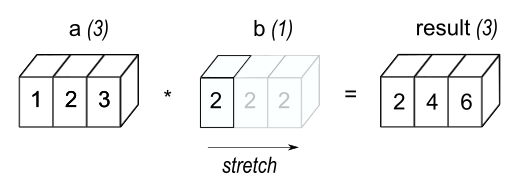

*Figure 1. The scalar `b = 2` is "stretched" to match the shape of `a` (3,), giving `[2, 4, 6]`. Conceptually `b` becomes `[2, 2, 2]`, but NumPy never actually makes that copy in memory. Image source: NumPy Developers, [Broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html), NumPy User Guide.[1]*

### Example 2: When Shapes Don't Match

In [2]:
a = np.array([[ 0,  0,  0],
              [10, 10, 10],
              [20, 20, 20],
              [30, 30, 30]])   # Shape: (4, 3)
b = np.array([1, 2, 3, 4])     # Shape: (4,)

print("a shape:", a.shape)
print("b shape:", b.shape)
print("The last dimensions are 3 and 4, so these shapes are incompatible!")

try:
    result = a + b
except ValueError as e:
    print("Error:", e)

a shape: (4, 3)
b shape: (4,)
The last dimensions are 3 and 4, so these shapes are incompatible!
Error: operands could not be broadcast together with shapes (4,3) (4,) 


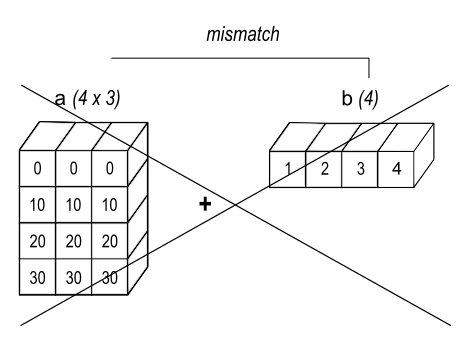

*Figure 3. Broadcasting compares shapes starting from the last dimension. `a` has 3 columns but `b` has 4 elements, and 3 ≠ 4, so `a + b` fails. Image source: NumPy Developers, [Broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html), NumPy User Guide.[1]*

### Example 3: Making Shapes Compatible
We can reshape `b` from Example 2 into a column so that broadcasting works:

In [3]:
a = np.array([[ 0,  0,  0],
              [10, 10, 10],
              [20, 20, 20],
              [30, 30, 30]])   # Shape: (4, 3)
b = np.array([1, 2, 3, 4])     # Shape: (4,)

# Reshape 'b' to be a column (4×1)
b_column = b[:, np.newaxis]    # Shape: (4, 1)

print("b =", b)
print("b_column =")
print(b_column)
print()

print("a shape:", a.shape)
print("Original b shape:", b.shape)
print("Reshaped b_column shape:", b_column.shape)
print()

result = a + b_column          # Broadcasting works now!
print("a + b_column =")
print(result)
print()
print("Explanation: each row of a gets one value of b added to it")
print("Row 1: [ 0,  0,  0] + 1 = [ 1,  1,  1]")
print("Row 2: [10, 10, 10] + 2 = [12, 12, 12]")
print("Row 3: [20, 20, 20] + 3 = [23, 23, 23]")
print("Row 4: [30, 30, 30] + 4 = [34, 34, 34]")

b = [1 2 3 4]
b_column =
[[1]
 [2]
 [3]
 [4]]

a shape: (4, 3)
Original b shape: (4,)
Reshaped b_column shape: (4, 1)

a + b_column =
[[ 1  1  1]
 [12 12 12]
 [23 23 23]
 [34 34 34]]

Explanation: each row of a gets one value of b added to it
Row 1: [ 0,  0,  0] + 1 = [ 1,  1,  1]
Row 2: [10, 10, 10] + 2 = [12, 12, 12]
Row 3: [20, 20, 20] + 3 = [23, 23, 23]
Row 4: [30, 30, 30] + 4 = [34, 34, 34]


## Understanding Array Shapes

### Creating Different Shapes

In [15]:
arr = np.array([1, 2, 3])         # 1D array, shape: (3,)

# Make it a column vector (3 rows, 1 column)
column = arr[:, np.newaxis]       # Shape: (3, 1)

# Make it a row vector (1 row, 3 columns)  
row = arr[np.newaxis, :]          # Shape: (1, 3)

print("Original array:")
print(arr)
print("Shape:", arr.shape)
print()

print("Column vector:")
print(column)
print("Shape:", column.shape)
print()

print("Row vector:")
print(row)
print("Shape:", row.shape)

Original array:
[1 2 3]
Shape: (3,)

Column vector:
[[1]
 [2]
 [3]]
Shape: (3, 1)

Row vector:
[[1 2 3]]
Shape: (1, 3)


## More Examples
Matrix + row vector (broadcasting happens automatically!)

In [16]:
# Matrix + row vector
a = np.array([[ 0,  0,  0],
              [10, 10, 10],
              [20, 20, 20],
              [30, 30, 30]])   # Shape: (4, 3)
b = np.array([1, 2, 3])        # Shape: (3,)

print("a:")
print(a)
print("a shape:", a.shape)
print()

print("b:", b)
print("b shape:", b.shape)
print()

result = a + b                 # Broadcasting works automatically!
print("a + b:")
print(result)
print()
print("What happened: b is added to every row of a")
print("Row 1: [ 0,  0,  0] + [1, 2, 3] = [ 1,  2,  3]")
print("Row 2: [10, 10, 10] + [1, 2, 3] = [11, 12, 13]")
print("Row 3: [20, 20, 20] + [1, 2, 3] = [21, 22, 23]")
print("Row 4: [30, 30, 30] + [1, 2, 3] = [31, 32, 33]")

a:
[[ 0  0  0]
 [10 10 10]
 [20 20 20]
 [30 30 30]]
a shape: (4, 3)

b: [1 2 3]
b shape: (3,)

a + b:
[[ 1  2  3]
 [11 12 13]
 [21 22 23]
 [31 32 33]]

What happened: b is added to every row of a
Row 1: [ 0,  0,  0] + [1, 2, 3] = [ 1,  2,  3]
Row 2: [10, 10, 10] + [1, 2, 3] = [11, 12, 13]
Row 3: [20, 20, 20] + [1, 2, 3] = [21, 22, 23]
Row 4: [30, 30, 30] + [1, 2, 3] = [31, 32, 33]


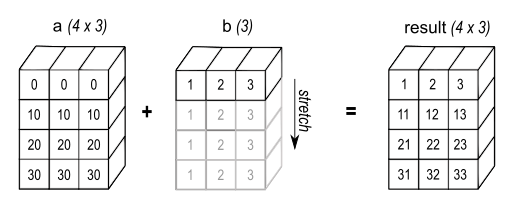

*Figure 2. `b` of shape (3,) matches the 3 columns of `a` (4, 3), so it is stretched down all 4 rows. Compare with Figure 3: there `b` had 4 elements, which did not match the 3 columns. Image source: NumPy Developers, [Broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html), NumPy User Guide.[1]*

## Key Rules for Broadcasting
1. **Same shapes**: Operations work element by element
2. **Different shapes**: NumPy tries to "stretch" the smaller array
3. **Incompatible shapes**: Use `np.newaxis` to add dimensions
4. **Scalars always work**: Single numbers broadcast to any array shape

## Tips
- [:, np.newaxis] makes a column vector (adds dimension on the right)
- [np.newaxis, :] makes a row vector (adds dimension on the left)
- Think of broadcasting as copying values to make arrays the same size
- Start with simple examples and build up to more complex ones

## References
[1] NumPy Developers. "Broadcasting." *NumPy User Guide*. https://numpy.org/doc/stable/user/basics.broadcasting.html (accessed September 23, 2026). Figures 1–3 are reproduced from this page.

---
## Creating Ranges of Values: linspace vs. logspace
`np.linspace(start, stop, num)` creates evenly spaced values between `start` and `stop` — the numbers you pass in are the actual endpoints.

`np.logspace(start, stop, num)` creates values evenly spaced **on a log scale** — but `start` and `stop` are the **exponents** applied to a base (10 by default), not the endpoint values themselves!

In [17]:
# linspace: start and stop ARE the endpoint values
lin_vals = np.linspace(1, 10, 5)
print("linspace(1, 10, 5) =", lin_vals)

# logspace: start and stop are EXPONENTS (base 10 by default)
# This goes from 10**0 to 10**2, i.e. 1 to 100 -- not "1 to 2"!
log_vals = np.logspace(0, 2, 5)
print("logspace(0, 2, 5) =", log_vals)

linspace(1, 10, 5) = [ 1.    3.25  5.5   7.75 10.  ]
logspace(0, 2, 5) = [  1.           3.16227766  10.          31.6227766  100.        ]


---
## Numerical Integration with TRAPZ

### The exact integral
We will integrate $f(x) = x^2$ from $0$ to $10$. Analytically:

$$\int_0^{10} x^2 \, dx = \left[\frac{x^3}{3}\right]_0^{10} = \frac{10^3}{3} - \frac{0^3}{3} = \frac{1000}{3} \approx 333.33$$

### The trapezoidal rule
`np.trapz` approximates the area under the curve by splitting $[a, b]$ into small intervals and replacing the curve on each interval with a straight line. Each piece is then a **trapezoid** with area $\text{width} \times \text{average height}$:

$$\int_a^b f(x)\,dx \;\approx\; \sum_{i=0}^{n-1} (x_{i+1} - x_i)\,\frac{f(x_i) + f(x_{i+1})}{2}$$

When the points are evenly spaced with step $h = \dfrac{b-a}{n}$, this simplifies to:

$$\int_a^b f(x)\,dx \;\approx\; \frac{h}{2}\Big[f(x_0) + 2f(x_1) + 2f(x_2) + \cdots + 2f(x_{n-1}) + f(x_n)\Big]$$

The interior points are counted twice because each one is shared by two neighbouring trapezoids.

In [4]:
import numpy as np
x = np.arange(0, 10)  # Creating an array of x values from 0 to 9
y = x**2  # Computing y as the square of x (y = x^2)
int_result = np.trapz(y, x)  # Using the trapezoidal rule to integrate y with respect to x
print('int_result=', int_result) # Printing the integral
print('10**3/3=', 10**3/3) # Printing the analytical solution

int_result= 244.5
10**3/3= 333.3333333333333


In [5]:
# Using more points for better accuracy
x = np.linspace(0, 10, 100)  # Creating 100 evenly spaced x values from 0 to 10
y = x**2  # Recomputing y as the square of x
int_result = np.trapz(y, x)  # Performing trapezoidal integration again
print('int_result=', int_result) # Printing the integral
print('10**3/3=', 10**3/3) # Printing the analytical solution

int_result= 333.35033840084344
10**3/3= 333.3333333333333


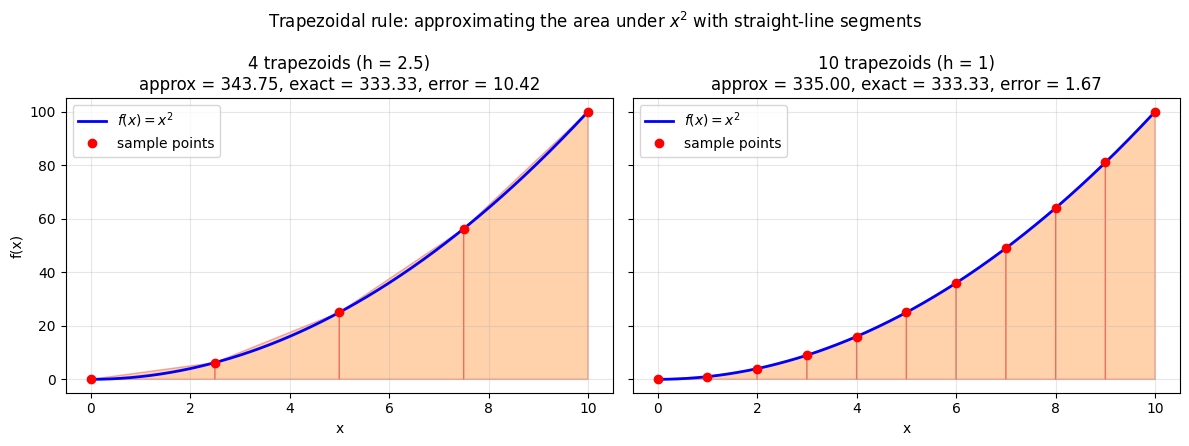

In [25]:
import matplotlib.pyplot as plt

f = lambda x: x**2
x_fine = np.linspace(0, 10, 400)          # smooth curve for the exact function

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, n in zip(axes, [4, 10]):          # number of trapezoids in each panel
    x = np.linspace(0, 10, n + 1)         # n intervals need n + 1 points
    y = f(x)
    h = x[1] - x[0]

    # Draw each trapezoid: corners (x_i, 0), (x_i, y_i), (x_i+1, y_i+1), (x_i+1, 0)
    for i in range(n):
        ax.fill([x[i], x[i], x[i+1], x[i+1]], [0, y[i], y[i+1], 0],
                facecolor='tab:orange', edgecolor='tab:red', alpha=0.35)

    ax.plot(x_fine, f(x_fine), 'b-', lw=2, label=r'$f(x) = x^2$')
    ax.plot(x, y, 'ro', label='sample points')

    # Trapezoidal rule, written out by hand to match the formula above
    approx = h / 2 * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])
    exact = 1000 / 3
    ax.set_title(f'{n} trapezoids (h = {h:g})\n'
                 f'approx = {approx:.2f}, exact = {exact:.2f}, error = {approx - exact:.2f}')
    ax.set_xlabel('x')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('f(x)')
fig.suptitle('Trapezoidal rule: approximating the area under $x^2$ with straight-line segments')
plt.tight_layout()
plt.show()

In [6]:
help(np.trapz)

Help on function trapz in module numpy:

trapz(y, x=None, dx=1.0, axis=-1)
    Integrate along the given axis using the composite trapezoidal rule.
    
    If `x` is provided, the integration happens in sequence along its
    elements - they are not sorted.
    
    Integrate `y` (`x`) along each 1d slice on the given axis, compute
    :math:`\int y(x) dx`.
    When `x` is specified, this integrates along the parametric curve,
    computing :math:`\int_t y(t) dt =
    \int_t y(t) \left.\frac{dx}{dt}\right|_{x=x(t)} dt`.
    
    Parameters
    ----------
    y : array_like
        Input array to integrate.
    x : array_like, optional
        The sample points corresponding to the `y` values. If `x` is None,
        the sample points are assumed to be evenly spaced `dx` apart. The
        default is None.
    dx : scalar, optional
        The spacing between sample points when `x` is None. The default is 1.
    axis : int, optional
        The axis along which to integrate.
    
    R